<a href="https://colab.research.google.com/github/nguyenthaibaok5bt-png/THDeepLearning/blob/main/THDeepLearningB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kích thước tập huấn luyện: (50000, 32, 32, 3)
Kích thước tập kiểm tra: (10000, 32, 32, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.3247 - loss: 1.8720 - val_accuracy: 0.3672 - val_loss: 1.7480
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.3992 - loss: 1.6695 - val_accuracy: 0.4190 - val_loss: 1.6209
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.4352 - loss: 1.5824 - val_accuracy: 0.4516 - val_loss: 1.5326
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.4553 - loss: 1.5270 - val_accuracy: 0.4571 - val_loss: 1.5148
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.4717 - loss: 1.4867 - val_accuracy: 0.4662 - val_loss: 1.5213
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.4835 - loss: 1.4490 - val_accuracy: 0.4785 - val_loss: 1.4685
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.4940 - loss: 1.4186 - val_accuracy: 0.4858 - val_loss: 1.4476
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - accuracy: 0.5038 - loss: 1.3910 - 

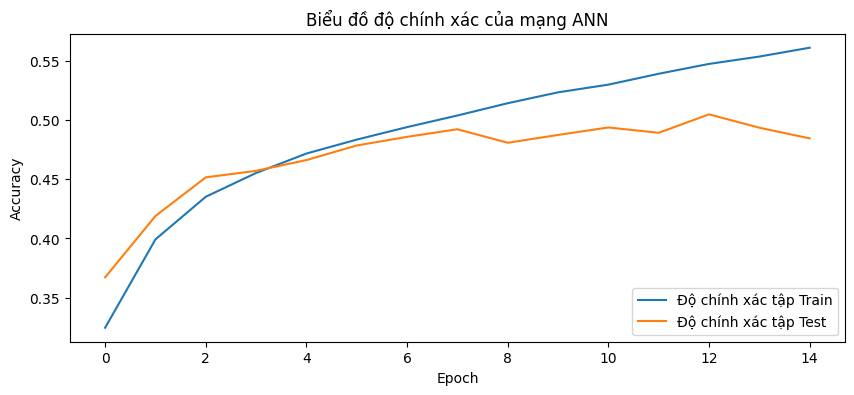

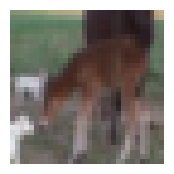

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Nhãn thực tế (Actual): horse
Mô hình dự đoán (Predicted): deer


In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


# Tải dataset có sẵn từ tensorflow
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Chuẩn hóa giá trị điểm ảnh về khoảng [0, 1] để mô hình hội tụ nhanh hơn
X_train, X_test = X_train / 255.0, X_test / 255.0

# Định nghĩa danh sách các nhãn tương ứng với bài toán
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Chuyển mảng y từ dạng 2D sang 1D để tiện xử lý dữ liệu nhãn
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")


model = models.Sequential([
    # Bước phẳng hóa ảnh từ dạng ma trận 3D (32, 32, 3) thành vector 1 chiều (3072,)
    layers.Flatten(input_shape=(32, 32, 3)),

    # Lớp ẩn thứ nhất với 512 neuron và hàm kích hoạt ReLU
    layers.Dense(512, activation='relu'),

    # Lớp ẩn thứ hai với 256 neuron
    layers.Dense(256, activation='relu'),

    # Lớp ẩn thứ ba với 128 neuron
    layers.Dense(128, activation='relu'),

    # Lớp đầu ra với 10 neuron tương ứng với 10 lớp phân loại của bài toán
    layers.Dense(10, activation='softmax')
])

# Hiển thị cấu trúc chi tiết của mạng
model.summary()


model.compile(
    optimizer='adam',                                     # Thuật toán tối ưu Adam
    loss='sparse_categorical_crossentropy',               # Hàm mất mát cho nhãn dạng số nguyên (0-9)
    metrics=['accuracy']                                  # Đánh giá bằng độ chính xác (accuracy)
)


# Huấn luyện trong 15 epochs, sử dụng tập test làm dữ liệu validation trực tiếp
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test), batch_size=64)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\n Độ chính xác trên tập kiểm tra (Test Accuracy): {test_acc*100:.2f}%")

# Vẽ đồ thị biểu diễn độ chính xác qua từng Epoch
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Độ chính xác tập Train')
plt.plot(history.history['val_accuracy'], label='Độ chính xác tập Test')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Biểu đồ độ chính xác của mạng ANN')
plt.show()

# Lấy ngẫu nhiên 1 chỉ số (index) từ 0 đến số lượng ảnh trong tập Test
idx = np.random.randint(0, len(X_test))

# Hiển thị ảnh kiểm tra ngẫu nhiên đó
plt.figure(figsize=(2, 2))
plt.imshow(X_test[idx])
plt.axis('off')
plt.show()

# Đưa ảnh qua mô hình để dự đoán (Cần reshape về dạng batch có kích thước là 1)
y_pred = model.predict(X_test[idx].reshape(1, 32, 32, 3))
predicted_label = class_names[np.argmax(y_pred)]
actual_label = class_names[y_test[idx]]

print(f"Nhãn thực tế (Actual): {actual_label}")
print(f"Mô hình dự đoán (Predicted): {predicted_label}")

Kích thước tập huấn luyện: (26048, 100)
Kích thước tập kiểm tra: (6513, 100)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8173 - loss: 0.3944 - val_accuracy: 0.8435 - val_loss: 0.3354
Epoch 2/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8390 - loss: 0.3435 - val_accuracy: 0.8508 - val_loss: 0.3226
Epoch 3/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8485 - loss: 0.3275 - val_accuracy: 0.8531 - val_loss: 0.3195
Epoch 4/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8499 - loss: 0.3235 - val_accuracy: 0.8563 - val_loss: 0.3147
Epoch 5/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8534 - loss: 0.3162 - val_accuracy: 0.8587 - val_loss: 0.3123
Epoch 6/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8548 - loss: 0.3123 - val_accuracy: 0.8589 - val_loss: 0.3120
Epoch 7/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8552 - loss: 0.3100 - val_accuracy: 0.8598 - val_loss: 0.3088
Epoch 8/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8557 - loss: 0.3088 - val_accuracy: 0.

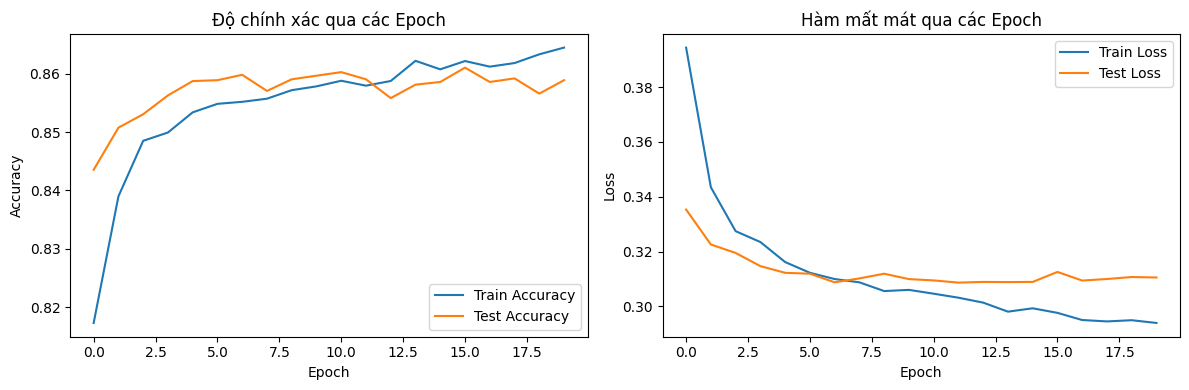

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

--- KẾT QUẢ DỰ ĐOÁN THỬ NGHIỆM TRÊN 5 MẪU ĐẦU TIÊN ---
Mẫu 1 -> Dự đoán: <=50K (Xác suất: 0.0047) | Thực tế: <=50K
Mẫu 2 -> Dự đoán: >50K (Xác suất: 0.5922) | Thực tế: <=50K
Mẫu 3 -> Dự đoán: >50K (Xác suất: 0.7175) | Thực tế: >50K
Mẫu 4 -> Dự đoán: <=50K (Xác suất: 0.0044) | Thực tế: <=50K
Mẫu 5 -> Dự đoán: <=50K (Xác suất: 0.0861) | Thực tế: <=50K


In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt


# Đường dẫn tải trực tiếp bộ dữ liệu Adult từ UCI Machine Learning Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# Định nghĩa tên các cột tương ứng với cấu trúc dữ liệu
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "gamma-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

# Đọc file CSV (Dữ liệu có chứa khoảng trắng thừa sau dấu phẩy nên ta dùng skipinitialspace=True)
df = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)

# Xử lý các giá trị bị khuyết (NaN) bằng cách điền giá trị xuất hiện nhiều nhất (mode)
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Tách riêng đặc trưng (X) và nhãn mục tiêu (y)
X = df.drop("income", axis=1)
y = df["income"]

# Mã hóa nhãn đầu ra (income): <=50K thành 0, >50K thành 1
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Mã hóa các cột dạng chữ (Categorical) bằng phương pháp One-Hot Encoding
categorical_cols = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Chuyển đổi toàn bộ dữ liệu X sang kiểu số thực float32 để tương thích tốt với TensorFlow
X = X.astype(np.float32)

# Chia tập dữ liệu thành 80% Huấn luyện (Train) và 20% Kiểm tra (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa (Scale) các đặc trưng dạng số để đưa về cùng phân phối (Mean=0, Std=1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")


model = models.Sequential([
    # Lớp ẩn đầu tiên nhận đầu vào tự động khớp với số lượng đặc trưng sau khi One-hot
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2), # Giảm thiểu overfitting

    # Lớp ẩn thứ hai
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    # Lớp đầu ra: 1 neuron và hàm sigmoid để tính xác suất thuộc nhóm >50K (từ 0 đến 1)
    layers.Dense(1, activation='sigmoid')
])

# Hiển thị tóm tắt cấu trúc mạng
model.summary()


model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Hàm mất mát chuyên dụng cho phân loại 2 lớp
    metrics=['accuracy']
)


history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n Độ chính xác trên tập kiểm tra (Test Accuracy): {test_acc*100:.2f}%")

# Vẽ đồ thị Loss và Accuracy của quá trình học
plt.figure(figsize=(12, 4))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Độ chính xác qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Hàm mất mát qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


sample_predictions = model.predict(X_test[:5])
print("\n--- KẾT QUẢ DỰ ĐOÁN THỬ NGHIỆM TRÊN 5 MẪU ĐẦU TIÊN ---")
for i in range(5):
    # Vì đầu ra qua sigmoid là xác suất, nếu > 0.5 thì tính là nhãn 1 (>50K)
    pred_label = ">50K" if sample_predictions[i][0] > 0.5 else "<=50K"
    true_label = ">50K" if y_test[i] == 1 else "<=50K"
    print(f"Mẫu {i+1} -> Dự đoán: {pred_label} (Xác suất: {sample_predictions[i][0]:.4f}) | Thực tế: {true_label}")

Kích thước tập huấn luyện: (1382, 21)
Kích thước tập kiểm tra: (346, 21)
Các lớp chất lượng xe cần phân loại: ['acc' 'good' 'unacc' 'vgood']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,084 (15.95 KB)

 Trainable params: 4,084 (15.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5941 - loss: 1.0683 - val_accuracy: 0.6792 - val_loss: 0.7520
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7149 - loss: 0.6365 - val_accuracy: 0.6994 - val_loss: 0.5373
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7959 - loss: 0.4762 - val_accuracy: 0.8468 - val_loss: 0.3979
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8538 - loss: 0.3672 - val_accuracy: 0.8728 - val_loss: 0.3144
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8719 - loss: 0.2961 - val_accuracy: 0.8873 - val_loss: 0.2501
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9081 - loss: 0.2356 - val_accuracy: 0.9104 - val_loss: 0.2035
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9240 - loss: 0.2000 - val_accuracy: 0.9509 - val_loss: 0.1762
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9356 - loss: 0.1716 - val_accuracy: 0.9595 - val_loss:

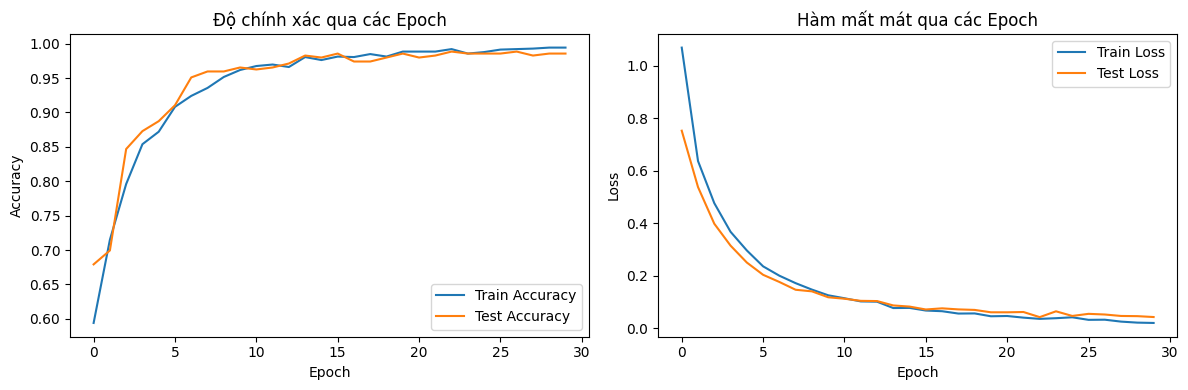


--- KẾT QUẢ DỰ ĐOÁN THỬ NGHIỆM TRÊN TẬP TEST ---
Mẫu xe index 162 -> Thực tế: unacc  | Mô hình dự đoán: unacc 
Mẫu xe index 305 -> Thực tế: unacc  | Mô hình dự đoán: unacc 
Mẫu xe index 16 -> Thực tế: unacc  | Mô hình dự đoán: unacc 
Mẫu xe index 31 -> Thực tế: unacc  | Mô hình dự đoán: unacc 
Mẫu xe index 230 -> Thực tế: unacc  | Mô hình dự đoán: unacc 


In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


# Đường dẫn tải trực tiếp bộ dữ liệu Car từ kho lưu trữ dữ liệu UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"

# Định nghĩa tiêu đề 7 cột theo cấu trúc chuẩn của dataset
columns = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]

# Đọc dữ liệu từ URL
df = pd.read_csv(url, names=columns)

# Tách đặc trưng (X) và nhãn mục tiêu chất lượng xe (y)
X = df.drop("class", axis=1)
y = df["class"]

# --- Xử lý Nhãn mục tiêu (y) ---
# Mã hóa nhãn dạng chữ (unacc, acc, good, vgood) thành dạng số (0, 1, 2, 3)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Chuyển đổi số nguyên thành ma trận One-Hot (vì bài toán này có 4 lớp đầu ra)
y_onehot = to_categorical(y_encoded)
num_classes = y_onehot.shape[1]  # Sẽ là 4 lớp

# --- Xử lý Đặc trưng đầu vào (X) ---
# Biến đổi các cột thuộc tính dạng chữ sang dạng số bằng One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=False)
X_encoded = X_encoded.astype(np.float32) # Chuyển kiểu dữ liệu sang float32 cho phù hợp ANN

# Chia dữ liệu: 80% để huấn luyện (Train) và 20% để kiểm tra (Test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_onehot, test_size=0.2, random_state=42)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")
print(f"Các lớp chất lượng xe cần phân loại: {label_encoder.classes_}")


model = models.Sequential([
    # Lớp ẩn thứ nhất: Tự động nhận số lượng đặc trưng sau khi mã hóa dữ liệu
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.1), # Giảm overfitting nhỏ

    # Lớp ẩn thứ hai
    layers.Dense(32, activation='relu'),

    # Lớp ẩn thứ ba
    layers.Dense(16, activation='relu'),

    # Lớp đầu ra: 4 neuron tương ứng 4 lớp chất lượng xe, dùng hàm kích hoạt 'softmax'
    layers.Dense(num_classes, activation='softmax')
])

# Hiển thị bảng tóm tắt cấu trúc mạng
model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Hàm mất mát cho nhãn đã mã hóa One-Hot đa lớp
    metrics=['accuracy']
)


# Huấn luyện mô hình trong 30 epoch
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n Độ chính xác trên tập kiểm tra (Test Accuracy): {test_acc*100:.2f}%")

# Vẽ đồ thị trực quan hóa quá trình học tập
plt.figure(figsize=(12, 4))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Độ chính xác qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Hàm mất mát qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# Chọn ngẫu nhiên 5 chỉ số từ tập dữ liệu test
random_indices = np.random.choice(len(X_test), size=5, replace=False)

print("\n--- KẾT QUẢ DỰ ĐOÁN THỬ NGHIỆM TRÊN TẬP TEST ---")
for idx in random_indices:
    # Lấy dữ liệu của mẫu thứ idx
    sample_x = X_test.iloc[[idx]] if isinstance(X_test, pd.DataFrame) else X_test[[idx]]
    sample_y_true = y_test[idx]

    # Dự đoán bằng mô hình
    pred_probs = model.predict(sample_x, verbose=0)

    # Giải mã từ index số ngược lại thành chuỗi nhãn gốc (ví dụ: unacc, acc)
    pred_label = label_encoder.inverse_transform([np.argmax(pred_probs)])[0]
    true_label = label_encoder.inverse_transform([np.argmax(sample_y_true)])[0]

    print(f"Mẫu xe index {idx} -> Thực tế: {true_label:<6} | Mô hình dự đoán: {pred_label:<6}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước tập huấn luyện: (60000, 28, 28)
Kích thước tập kiểm tra: (10000, 28, 28)


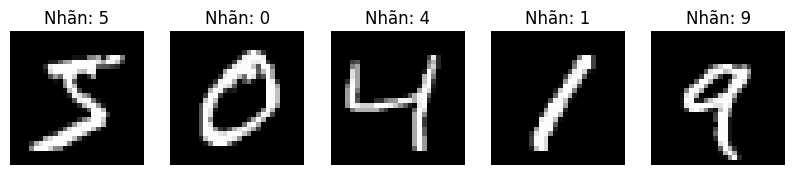

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9190 - loss: 0.2836 - val_accuracy: 0.9551 - val_loss: 0.1438
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9656 - loss: 0.1142 - val_accuracy: 0.9646 - val_loss: 0.1115
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9759 - loss: 0.0791 - val_accuracy: 0.9718 - val_loss: 0.0899
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9810 - loss: 0.0597 - val_accuracy: 0.9692 - val_loss: 0.1045
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9848 - loss: 0.0485 - val_accuracy: 0.9757 - val_loss: 0.0776
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9880 - loss: 0.0378 - val_accuracy: 0.9747 - val_loss: 0.0843
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9903 - loss: 0.0302 - val_accuracy: 0.9746 - val_loss: 0.0891
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9918 - loss: 0.0254 - val_accuracy: 0.

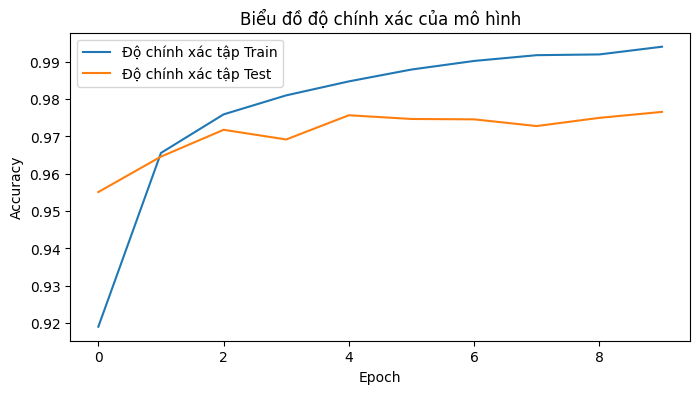

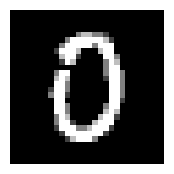

Nhãn thực tế (Actual): 0
Mô hình dự đoán (Predicted): 0


In [6]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


# Tải bộ dữ liệu chữ số viết tay MNIST tích hợp sẵn trong TensorFlow
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

# Chuẩn hóa dữ liệu ảnh từ khoảng [0, 255] về [0, 1] để mạng học ổn định hơn
X_train, X_test = X_train / 255.0, X_test / 255.0

print(f"Kích thước tập huấn luyện: {X_train.shape}")  # (60000, 28, 28)
print(f"Kích thước tập kiểm tra: {X_test.shape}")    # (10000, 28, 28)

# Hiển thị thử 5 hình ảnh đầu tiên trong tập dữ liệu
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Nhãn: {y_train[i]}")
    plt.axis('off')
plt.show()


model = models.Sequential([
    # Phẳng hóa ảnh từ ma trận 2D (28 x 28) thành vector 1D (784 phần tử)
    layers.Flatten(input_shape=(28, 28)),

    # Lớp ẩn thứ nhất với 128 neuron, hàm kích hoạt ReLU
    layers.Dense(128, activation='relu'),

    # Lớp ẩn thứ hai với 64 neuron, hàm kích hoạt ReLU
    layers.Dense(64, activation='relu'),

    # Lớp đầu ra với 10 neuron (tương ứng với các chữ số từ 0 đến 9)
    # Dùng hàm 'softmax' để xuất ra xác suất của từng chữ số
    layers.Dense(10, activation='softmax')
])

# Hiển thị cấu trúc chi tiết của mô hình
model.summary()


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Phù hợp cho nhãn dạng số nguyên từ 0-9
    metrics=['accuracy']
)


# Huấn luyện trong 10 epoch với batch_size là 64
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n Độ chính xác trên tập kiểm tra (Test Accuracy): {test_acc*100:.2f}%")

# Vẽ đồ thị biểu diễn độ chính xác (Accuracy) qua các vòng lặp (Epoch)
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Độ chính xác tập Train')
plt.plot(history.history['val_accuracy'], label='Độ chính xác tập Test')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Biểu đồ độ chính xác của mô hình')
plt.show()


# Chọn ngẫu nhiên một index trong tập test
random_idx = np.random.randint(0, len(X_test))
test_image = X_test[random_idx]

# Hiển thị hình ảnh được chọn
plt.figure(figsize=(2, 2))
plt.imshow(test_image, cmap='gray')
plt.axis('off')
plt.show()

# Dự đoán (Cần reshape ảnh về dạng batch kích thước (1, 28, 28))
prediction = model.predict(test_image.reshape(1, 28, 28), verbose=0)
predicted_digit = np.argmax(prediction)  # Lấy vị trí có xác suất cao nhất
actual_digit = y_test[random_idx]

print(f"Nhãn thực tế (Actual): {actual_digit}")
print(f"Mô hình dự đoán (Predicted): {predicted_digit}")